In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# Seismic Data Analysis with ObsPy Interoperability

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gwexpy/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_seismic_obspy.ipynb)

This tutorial demonstrates how to read seismological data in **MiniSEED / SAC / FDSN** formats and analyze it using gwexpy, with seamless conversion between `obspy` and gwexpy objects.

## Use cases in GW detector science
- Reading seismometer data from KAGRA, LIGO, or Virgo environment monitors
- Seismic noise analysis and coupling to detector sensitivity
- Cross-correlation of seismic channels with gravitational-wave data

**Legacy migration note:**  
If your code used `obspy.read()` directly followed by manual numpy processing, replace it with `TimeSeries.read(format='miniseed')` and gwexpy's high-level signal processing methods.  
See [API_MAPPING.md Category 4](https://github.com/tatsuki-washimi/gwexpy/blob/main/docs_internal/references/SampleCodes_GWpy/API_MAPPING.md) for the full interop reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

from gwexpy.timeseries import TimeSeries, TimeSeriesDict

# ObsPy is an optional dependency
try:
    import obspy
    OBSPY_AVAILABLE = True
    print(f"ObsPy version: {obspy.__version__}")
except ImportError:
    OBSPY_AVAILABLE = False
    print("ObsPy not installed. Install with: pip install obspy")
    print("This tutorial will show the API but skip cells requiring obspy.")

ObsPy version: 1.4.2


## 1. Route 1: `TimeSeries.read(format='miniseed')`

gwexpy's I/O layer supports reading MiniSEED files directly, returning a `TimeSeries` object with correct units and time axis.

In [2]:
# --- Route 1: Read MiniSEED via gwexpy I/O ---
# Replace the path below with your actual MiniSEED file
#
# ts_seismic = TimeSeries.read(
#     "path/to/seismic.mseed",
#     format='miniseed',
# )
#
# Or read SAC format:
# ts_seismic = TimeSeries.read("path/to/seismic.sac", format='sac')
#
# For FDSN web service (requires network access):
# ts_seismic = TimeSeries.read(
#     "IU.ANMO.00.BHZ",
#     format='miniseed',
#     start=1234567890,
#     end=1234568090,
# )

print("Route 1: TimeSeries.read(format='miniseed') or format='sac'")
print("This returns a TimeSeries with GPS time axis, units, and channel name.")

Route 1: TimeSeries.read(format='miniseed') or format='sac'
This returns a TimeSeries with GPS time axis, units, and channel name.


## 2. Route 2: `from_obspy_trace()` – Convert from obspy objects

If you already have an `obspy.Trace` or `obspy.Stream`, convert it to gwexpy with `from_obspy_trace()`.

In [3]:
if OBSPY_AVAILABLE:
    # Simulate obspy workflow
    # Normally: st = obspy.read("seismic.mseed")
    # Here we create a synthetic trace for demonstration
    rng = np.random.default_rng(0)
    fs_seis = 100.0  # 100 Hz seismometer
    n_seis  = 6000   # 60 seconds
    t_seis  = np.arange(n_seis) / fs_seis
    
    # Simulate seismic noise + Rayleigh wave
    seis_data = (
        1e-7 * rng.normal(0, 1, n_seis)              # broadband noise
        + 5e-7 * np.sin(2 * np.pi * 0.15 * t_seis)  # 0.15 Hz microseism
        + 2e-7 * np.sin(2 * np.pi * 1.0  * t_seis)  # 1 Hz noise
    )
    
    stats = obspy.core.Stats()
    stats.network  = "K1"
    stats.station  = "KAGRA"
    stats.location = "00"
    stats.channel  = "BHZ"
    stats.sampling_rate = fs_seis
    stats.starttime = obspy.UTCDateTime("2023-01-01T00:00:00")
    stats.npts = n_seis
    
    tr = obspy.Trace(data=seis_data, header=stats)
    print("obspy Trace:", tr)
    
    # Convert to gwexpy TimeSeries
    ts_seismic = TimeSeries.from_obspy_trace(tr, unit=u.m / u.s)
    print("\nConverted to TimeSeries:")
    print(f"  t0     = {ts_seismic.t0:.3f}")
    print(f"  dt     = {ts_seismic.dt}")
    print(f"  N      = {len(ts_seismic.value)}")
    print(f"  unit   = {ts_seismic.unit}")
    print(f"  name   = {ts_seismic.name}")
else:
    # Fallback: create synthetic data without obspy
    rng = np.random.default_rng(0)
    fs_seis = 100.0
    n_seis  = 6000
    t_seis  = np.arange(n_seis) / fs_seis
    seis_data = (
        1e-7 * rng.normal(0, 1, n_seis)
        + 5e-7 * np.sin(2 * np.pi * 0.15 * t_seis)
        + 2e-7 * np.sin(2 * np.pi * 1.0  * t_seis)
    )
    ts_seismic = TimeSeries(
        seis_data,
        dt=(1/fs_seis)*u.s,
        t0=0*u.s,
        unit=u.m/u.s,
        name="K1:KAGRA.BHZ",
    )
    print("Created synthetic TimeSeries (no obspy)")

obspy Trace: K1.KAGRA.00.BHZ | 2023-01-01T00:00:00.000000Z - 2023-01-01T00:00:59.990000Z | 100.0 Hz, 6000 samples

Converted to TimeSeries:
  t0     = 1356566418.000 s
  dt     = 0.01 s
  N      = 6000
  unit   = m / s
  name   = K1.KAGRA.00.BHZ


## 3. Signal Processing on Seismic Data

Once converted to `TimeSeries`, all gwexpy signal processing methods are available.

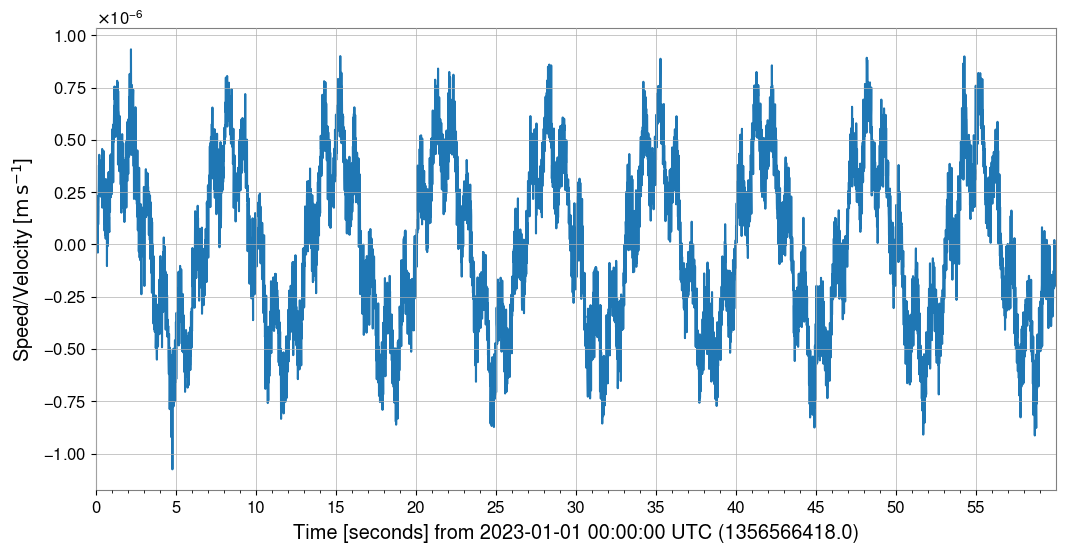

In [4]:
# Time domain plot
ts_seismic.plot(xscale='seconds');

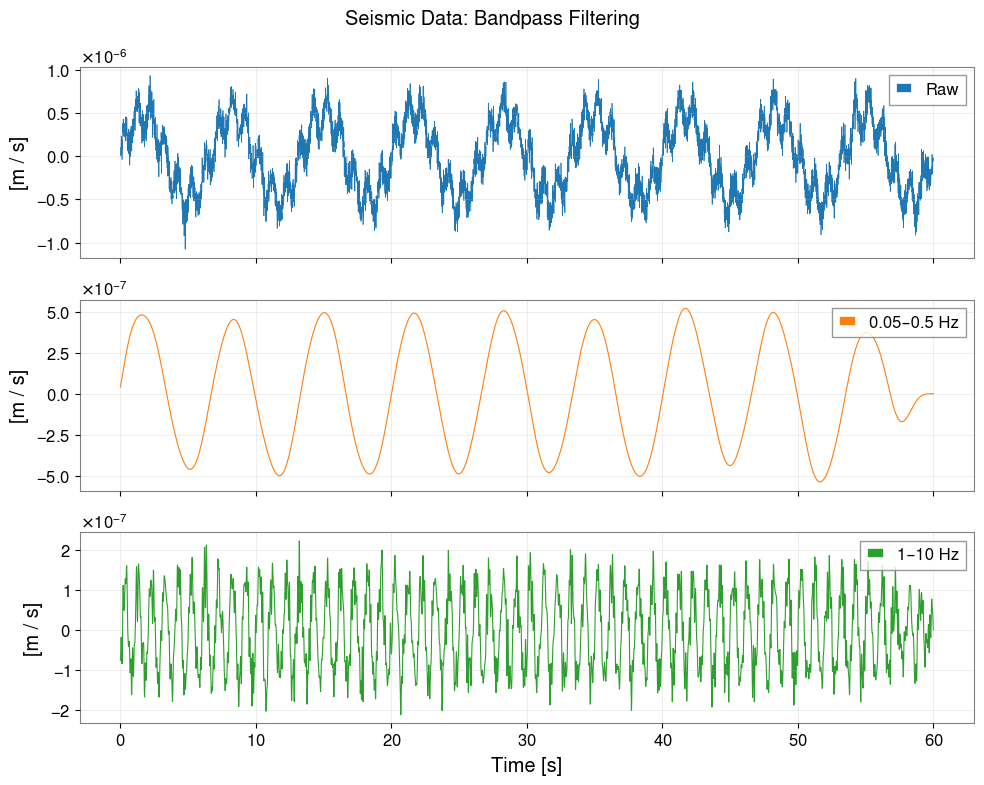

In [5]:
# Bandpass filter to isolate seismic bands
ts_lf  = ts_seismic.bandpass(0.05, 0.5)   # 0.05–0.5 Hz: Earth's hum + microseism
ts_hf  = ts_seismic.bandpass(1.0,  10.0)  # 1–10 Hz: human-induced noise

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(np.arange(len(ts_seismic.value)) / fs_seis, ts_seismic.value, lw=0.5, label="Raw")
axes[1].plot(np.arange(len(ts_lf.value))      / fs_seis, ts_lf.value,      lw=0.8, label="0.05–0.5 Hz", color="C1")
axes[2].plot(np.arange(len(ts_hf.value))      / fs_seis, ts_hf.value,      lw=0.8, label="1–10 Hz",    color="C2")

for ax in axes:
    ax.set_ylabel(f"[{ts_seismic.unit}]")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel("Time [s]")
fig.suptitle("Seismic Data: Bandpass Filtering")
plt.tight_layout()

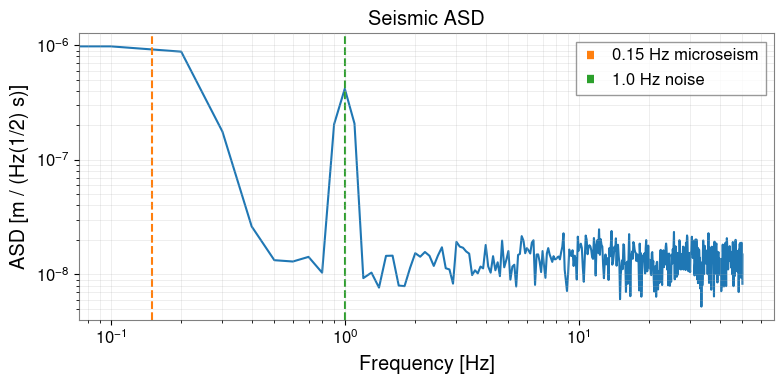

In [6]:
# Amplitude Spectral Density
asd = ts_seismic.asd(fftlength=10.0, overlap=0.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(asd.frequencies.value, asd.value)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(f"ASD [{asd.unit}]")
ax.set_title("Seismic ASD")
ax.grid(True, which="both", alpha=0.3)
# Annotate microseism peak
ax.axvline(0.15, color="C1", linestyle="--", label="0.15 Hz microseism")
ax.axvline(1.0,  color="C2", linestyle="--", label="1.0 Hz noise")
ax.legend()
plt.tight_layout()

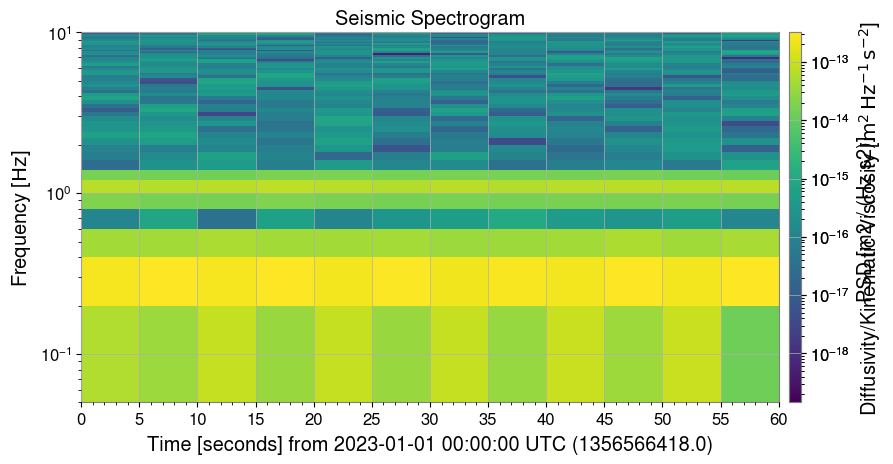

In [7]:
# Spectrogram: Time-frequency map
sg = ts_seismic.spectrogram(stride=5.0, fftlength=5.0, overlap=0.5)

plot = sg.plot()
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(0.05, 10)
ax.set_title("Seismic Spectrogram")
plot.colorbar(mappable=plt.gca().get_images()[-1] if plt.gca().get_images() else plt.gca().collections[-1], label=f"PSD [{sg[0, 0].unit if hasattr(sg, '__getitem__') else ''}]");

## 4. Convert Back to obspy

After gwexpy processing, convert the result back to obspy for further seismological analysis (e.g., instrument response removal, FDSN upload).

In [8]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

if OBSPY_AVAILABLE:
    # Convert processed TimeSeries back to obspy Trace
    tr_filtered = ts_lf.to_obspy_trace()
    print("Converted back to obspy Trace:", tr_filtered)
    
    # Or use the generic to_obspy dispatcher
    from gwexpy.interop import to_obspy
    tr_generic = to_obspy(ts_lf)
    print("via to_obspy():", tr_generic)
else:
    print("obspy not available – skipping round-trip conversion")

Converted back to obspy Trace: .K1.KAGRA.00.BHZ.. | 2023-01-01T00:00:00.000000Z - 2023-01-01T00:00:59.990000Z | 100.0 Hz, 6000 samples
via to_obspy(): .K1.KAGRA.00.BHZ.. | 2023-01-01T00:00:00.000000Z - 2023-01-01T00:00:59.990000Z | 100.0 Hz, 6000 samples


## 5. Multi-channel Seismic Analysis

When you have multiple seismic channels (3-component seismometer: X, Y, Z), use `TimeSeriesMatrix` for batch processing.

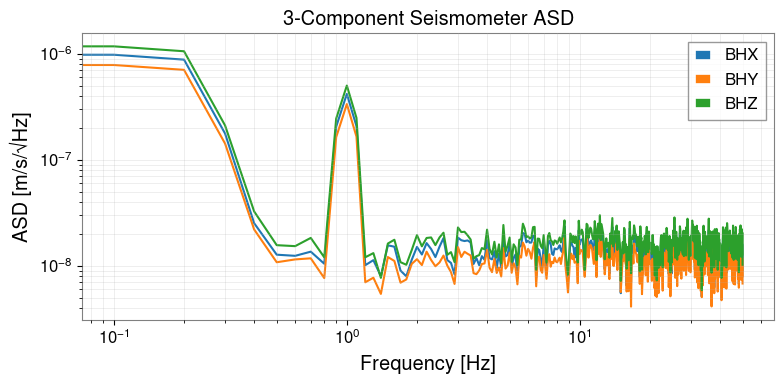

In [9]:
from gwexpy.timeseries import TimeSeriesMatrix

rng2 = np.random.default_rng(1)

# Three-component seismometer
components = ['BHX', 'BHY', 'BHZ']
data_3c = np.stack([
    seis_data + 1e-8 * rng2.normal(0, 1, n_seis),
    seis_data * 0.8 + 1e-8 * rng2.normal(0, 1, n_seis),
    seis_data * 1.2 + 1e-8 * rng2.normal(0, 1, n_seis),
], axis=0)[:, np.newaxis, :]  # (3, 1, n)

tsm_3c = TimeSeriesMatrix(
    data_3c,
    dt=(1/fs_seis)*u.s,
    t0=0*u.s,
    units=np.full((3, 1), u.m/u.s),
)
tsm_3c.channel_names = components

# ASD for all 3 components at once
asd_3c = tsm_3c.asd(fftlength=10.0, overlap=0.5)

fig, ax = plt.subplots(figsize=(8, 4))
for i, comp in enumerate(components):
    ax.loglog(asd_3c[i, 0].frequencies.value, asd_3c[i, 0].value, label=comp)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [m/s/√Hz]")
ax.set_title("3-Component Seismometer ASD")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()

## 6. Migration Guide: obspy → gwexpy

**Before (obspy + numpy):**
```python
import obspy
from scipy import signal
import numpy as np

st = obspy.read("seismic.mseed")
tr = st[0]

# Manual bandpass
tr_bp = tr.copy().filter('bandpass', freqmin=0.1, freqmax=1.0)

# Manual ASD with scipy
f, psd = signal.welch(tr.data, fs=tr.stats.sampling_rate, nperseg=1024)
asd = np.sqrt(psd)

# Manual spectrogram
f, t, Sxx = signal.spectrogram(tr.data, fs=tr.stats.sampling_rate)
```

**After (gwexpy):**
```python
from gwexpy.timeseries import TimeSeries

ts = TimeSeries.read("seismic.mseed", format='miniseed')
# Or: ts = TimeSeries.from_obspy_trace(obspy.read("seismic.mseed")[0])

ts_bp  = ts.bandpass(0.1, 1.0)
asd    = ts.asd(fftlength=10.0, overlap=0.5)         # FrequencySeries with units
sg     = ts.spectrogram(stride=5.0, fftlength=5.0)  # Spectrogram with GPS time axis

asd.plot()  # Ready to plot with correct units and axis labels
```

## Summary

| Task | gwexpy API |
|------|------------|
| Read MiniSEED file | `TimeSeries.read(path, format='miniseed')` |
| Read SAC file | `TimeSeries.read(path, format='sac')` |
| Convert from obspy Trace | `TimeSeries.from_obspy_trace(tr, unit=...)` |
| Convert to obspy Trace | `ts.to_obspy_trace()` or `to_obspy(ts)` |
| Bandpass filter | `ts.bandpass(fmin, fmax)` |
| ASD | `ts.asd(fftlength=..., overlap=...)` |
| Spectrogram | `ts.spectrogram(stride=..., fftlength=...)` |
| Multi-channel | `TimeSeriesMatrix` with element-wise operations |

**See also:**
- [Intro Interoperability](intro_interop.ipynb)
- [Coupling Function Analysis](advanced_coupling.ipynb)